## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Implementing Logistic Regression</p>

### Logistic Regression is a supervised machine learning algorithm used for classification problems. It predicts the probability that an observation belongs to a particular class. 

 In this project, car prices are classified as either Low Price or High Price. This transformation allows the model to classify each car into one of two categories instead of predicting its exact price.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset

In [3]:
# Load the dataset
df = pd.read_csv("../data/processed/auto_scout_final.csv")
df.shape

(15915, 140)

# Create a Binary Target

In [4]:
# Create a binary target variable based on the median price.
# 0 = Low Price, 1 = High Price

median_price = df["price"].median()

df["price_category"] = np.where(
    df["price"] >= median_price,
    1,
    0
)

df["price_category"].value_counts()

1    7986
0    7929
Name: price_category, dtype: int64

# Define Features and Target

In [5]:
X = df.drop(["price", "price_category"], axis=1)
y = df["price_category"]

# Remove Rare Dummy Variable

In [6]:
X = X.drop(columns=["make_model_Audi A2"])

# Split the Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Scale the Features

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the Logistic Regression Model

In [11]:
# max_iter increases the number of iterations to help the model converge.

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the Model

In [12]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

# Make Predictions

In [13]:
y_pred = log_model.predict(X_test_scaled)

# Evaluate the Model

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9472

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1607
           1       0.95      0.95      0.95      1576

    accuracy                           0.95      3183
   macro avg       0.95      0.95      0.95      3183
weighted avg       0.95      0.95      0.95      3183



# Confusion Matrix

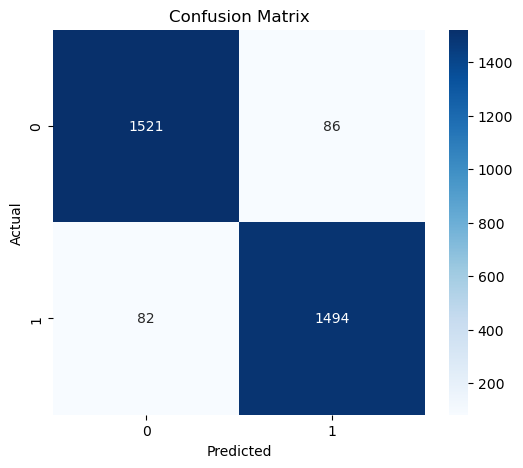

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Compare Predictions

In [16]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
12887,1,1
8140,1,0
6835,0,0
15439,1,1
1213,0,0
13187,0,0
1034,1,1
2864,0,1
7061,1,1
14983,1,1


#### The Logistic Regression model achieved an accuracy of 94.72%, demonstrating excellent performance in classifying cars into Low Price and High Price categories. The high precision, recall, and F1-score (0.95) indicate that the model accurately distinguished between the two classes with very few misclassifications. Overall, the model proved to be a reliable and effective binary classifier.